<a href="https://colab.research.google.com/github/aliasjadsyed07-rgb/Revenue-Trend-Analysis/blob/main/Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Sales Data to optimize pricing, promotions and market expansion for sustainable growth. Importing Libraries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sheets = pd.read_excel('/content/Regional Sales Dataset.xlsx', sheet_name=None)

In [ ]:
""" Assign dataframes to each sheet. A Pandas DataFrame is a two-dimensional, size-mutable,
and potentially heterogeneous tabular data structure with labeled axes (rows and columns).
It is the primary data structure in the Pandas library for Python and is widely used for data manipulation and analysis. """

df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_products = sheets['Products']
df_regions = sheets['Regions']
df_state_reg = sheets['State Regions']
df_budgets = sheets['2017 Budgets']

In [ ]:
"""In Pandas, the .SHAPE() attribute is used to return a tuple representing the dimensionality of a DataFrame or Series."""
print("df_sales shape: ", (df_sales.shape))
print("df_customers shape: ", (df_customers.shape))
print("df_products shape: ", (df_products.shape))
print("df_regions shape: ", (df_regions.shape))
print("df_state_reg shape: ", (df_state_reg.shape))
print("df_budgets shape: ", (df_budgets.shape))

df_sales shape:  (64104, 12)
df_customers shape:  (175, 2)
df_products shape:  (30, 2)
df_regions shape:  (994, 15)
df_state_reg shape:  (49, 3)
df_budgets shape:  (30, 2)


In [ ]:
#Removing the top row of the state reg table. ILOC[] used to select a row based on index
new_header = df_state_reg.iloc[0]
df_state_reg.columns = new_header
df_state_reg = df_state_reg[1:].reset_index(drop=True)

df_state_reg.head(5)

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [ ]:
""" The .ISNULL().SUM() method is commonly used in the Pandas library in Python to identify and
 count missing values (NaN or Null) within a DataFrame or Series. Means my data has no null values"""
df_sales.isnull().sum()


,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


## **Data Cleaning & Wrangling**

In [ ]:
"""Here's a breakdown of the parameters:
We used MERGE() to get the customer names from another table and put into our main one.

df_sales.merge(df_customers, ...): This is the core of the merge operation. It's taking df_sales and merging it with df_customers.
how='left': This specifies the type of merge. A 'left' merge keeps all rows from the left dataframe (df_sales) and matches them with rows from the right dataframe (df_customers) based on the specified keys. If a customer from df_sales doesn't have a match in df_customers, the columns from df_customers will have NaN (Not a Number) values for that row.
left_on='Customer Name Index': This is the key column in the df_sales dataframe that will be used for matching.
right_on='Customer Index': This is the key column in the df_customers dataframe that will be used for matching.
In essence, this code is adding customer information (like 'Customer Names') from df_customers to the df_sales dataframe based on the matching customer index."""

df = df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)



In [ ]:
# now we MERGE() the Products like we did with customers before. After this the products and customers subsheets will be irrelevant
# because we already merged them into the main one.

df = df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)


In [ ]:
# MERGE() regions into main
df = df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)


In [ ]:
# MERGE() state regions into main
df = df.merge(
    df_state_reg[["State Code", "Region"]],
    how='left',
    left_on='state_code',
    right_on='State Code'
)

In [ ]:
# MERGE() budgets into main
df = df.merge(
    df_budgets,
    how='left',
    on='Product Name'
)

In [ ]:
# Using .DROP(), now we will delete the columns that became repetitive after the merging

cols_to_drop = ['Customer Index', 'Index_y', 'Product Name_y', 'id', 'State Code', 'Index_x']
df = df.drop(columns = cols_to_drop, errors='ignore')


In [ ]:
df.to_csv('file.csv') #   CSV() creates the file in or folder in csv format

In [ ]:
# Convert all columns to lower case for consistency and easier acces
df.columns = df.columns.str.lower()

df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'index',
       'product name', 'name', 'county', 'state_code', 'state', 'type',
       'latitude', 'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [ ]:
cols_to_keep = [
    'ordernumber',
    'orderdate',
    'customer names',
    'channel',
    'product name',
    'order quantity',
    'unit price',
    'line total',
    'total unit cost',
    'state_code',
    'county',
    'state',
    'region',
    'latitude',
    'longitude',
    '2017 budgets'
]

In [ ]:
# the following code would mean that df is nothing except columns to keep I defined above
df = df[cols_to_keep]

In [ ]:
df.head(5)

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,total unit cost,state_code,county,state,region,latitude,longitude,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [ ]:
# Renaming the columns using RENAME()

df = df.rename(columns={
    'ordernumber': 'order_number',
   'orderdate': 'order_date',
   'customer names': 'customer_name',
    'product name': 'product_name',
    'order quantity': 'order_quantity',
    'unit price': 'unit_price',
    'line total': 'revenue',
    'total unit cost': 'cost',
    'state_code': 'state',
    'state': 'state_name',
    'latitude': 'lat',
    'longitude': 'lon',
    '2017 budgets': 'budget'
})

df.head(1)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231


In [ ]:
"""now we are going to blank out budgets which are non-2017 orders
This code snippet is doing two things:

Blanking out budgets for non-2017 orders:

df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA: This line uses .loc to select rows in the DataFrame df where the year extracted from the order_date column is not equal to 2017.
For these selected rows, it sets the value in the 'budget' column to pd.NA, which represents a missing or "not available" value in pandas. This effectively removes budget information for orders that did not occur in 2017.


Displaying the first 5 rows of specific columns:
df[['order_date', 'product_name', 'revenue', 'budget' ]].head(5): This line selects a subset of columns ('order_date', 'product_name', 'revenue', and 'budget')
from the modified df DataFrame and then displays the first 5 rows of this subset using .head(5). This allows you to quickly see the effect of the previous line, showing the order date, product name, revenue, and the updated budget column (with NaN for non-2017 orders).

In pandas, when you have a column that contains datetime objects (like the order_date column in your DataFrame),
 you can access various components of the date and time using the .dt accessor.
"""
df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA

df[['order_date', 'product_name', 'revenue', 'budget' ]].tail(5)


,order_date,product_name,revenue,budget
64099,2018-02-28,Product 26,21788.4,NaN
64100,2018-02-28,Product 21,5185.8,NaN
64101,2018-02-28,Product 13,43483.0,NaN
64102,2018-02-28,Product 20,27717.9,NaN
64103,2018-02-28,Product 15,7986.4,NaN


In [ ]:
# downloading the file to see latest changes
df.to_csv('final.csv')

In [ ]:
# The info() method in Pandas provides a concise summary of a DataFrame.
# This method is crucial for quickly understanding the structure and content of a dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_number    64104 non-null  object        
 1   order_date      64104 non-null  datetime64[ns]
 2   customer_name   64104 non-null  object        
 3   channel         64104 non-null  object        
 4   product_name    64104 non-null  object        
 5   order_quantity  64104 non-null  int64         
 6   unit_price      64104 non-null  float64       
 7   revenue         64104 non-null  float64       
 8   cost            64104 non-null  float64       
 9   state           64104 non-null  object        
 10  county          64104 non-null  object        
 11  state_name      64104 non-null  object        
 12  region          64104 non-null  object        
 13  lat             64104 non-null  float64       
 14  lon             64104 non-null  float64       
 15  bu

In [ ]:
# Now we filter the dataset to only include records from the year 2017
df_2017 = df[df['order_date'].dt.year == 2017]

In [ ]:
df.isnull().sum()

,0
order_number,0
order_date,0
customer_name,0
channel,0
product_name,0
order_quantity,0
unit_price,0
revenue,0
cost,0
state,0


In [ ]:
df_2017.head(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,Hudson County,New Jersey,Northeast,40.77955,-74.02375,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Mesa County,Colorado,West,39.06387,-108.55065,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,Los Angeles County,California,West,33.96168,-118.35313,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Dubuque County,Iowa,Midwest,42.50056,-90.66457,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Hernando County,Florida,South,28.47689,-82.52546,3050087.565


# **Feature Engineering**

In [ ]:
df.head(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN


In [ ]:
# Now we calculate the profit using the formula : Profit = Revenue - Total Cost
# Total Cost = Quantity * Total Unit Cost
# NOTE you have mentioned 'TOTAL UNIT COST' AS 'COST'

df['total_cost'] = df['order_quantity'] * df['cost']

In [ ]:
# We will also calculate the profit margin by using the profit margin formula
df['profit'] = df['revenue'] - df['total_cost']
df['profit_margin_pct'] = df['profit'] / df['revenue']*100

df.head(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0


# **Exploratory Data Analysis (EDA)**

In [ ]:
""" EDA is a method for summarizing and understanding the main characteristics of a dataset by using statistical summaries and data visualizations."""

' EDA is a method for summarizing and understanding the main characteristics of a dataset by using statistical summaries and data visualizations.'

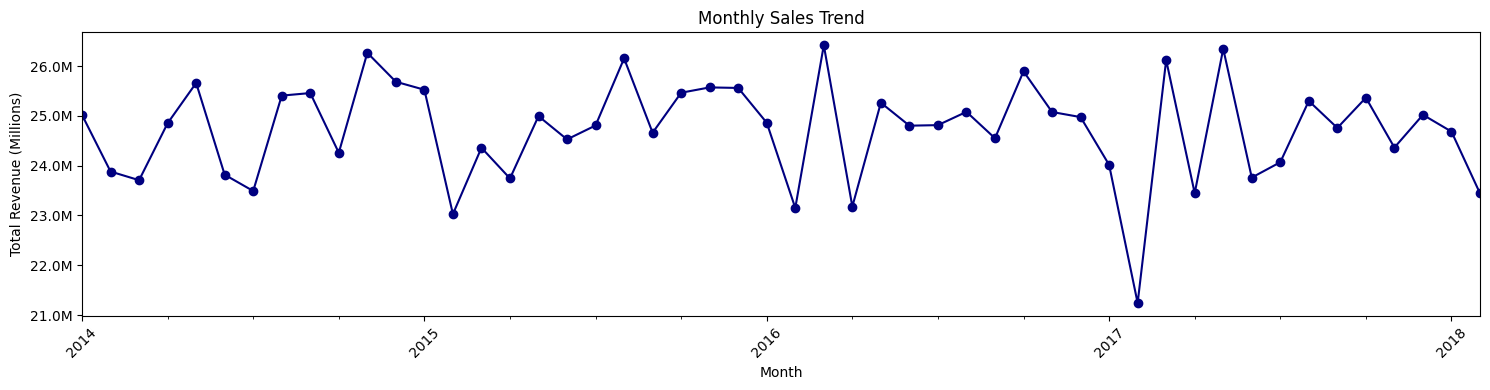

In [ ]:
""" We are sorting the data according to months now . We are now plotting a time series graph

This code helps us count how much money we made from selling toys each month, like counting how many stickers you earned each month in school!

df['order_month'] = df['order_date'].dt.to_period('M'): This is like putting a sticker on each toy that says which month you got it.
So, if you got a toy on January 15th, the sticker just says "January".
monthly_sales = df.groupby('order_month')['revenue'].sum(): Now, we put all the January toys together, all the February toys together, and so on.
Then, for each month's pile of toys, we add up all the money
we got for them. This tells us our total money for each month.
plt.figure(figsize=(15,4)): We're getting a big piece of paper ready to draw a picture of our money each month!
monthly_sales.plot(marker='o',color='navy'): Now we draw a line on our paper! We put a dot for how much money we made in January,
another dot for February, and we connect the dots. The line shows if we made more or less money each month. The dots are little circles, and the line is blue like the ocean.
from matplotlib.ticker import FuncFormatter and formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'): This is like making sure the numbers on our
drawing are easy to read. Instead of writing really long numbers, we write "10M" for 10 million, which is a super big number!
plt.gca().yaxis.set_major_formatter(formatter): We use our special number-writer to put the easy-to-read numbers on the side of our drawing.
plt.title('Monthly Sales Trend'): We write "How much money we made each month" at the top of our drawing so everyone knows what it is!
plt.xlabel('Month'): We write "Which Month" at the bottom.
plt.ylabel('Total Revenue (Millions)'): We write "Lots of Money" on the side.
plt.xticks(rotation=45): We turn the names of the months a little bit so they don't bump into each other.
plt.tight_layout(): We make sure everything on our drawing fits nicely on the paper.
plt.show(): And finally, we show our drawing to everyone!
"""

df['order_month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('order_month')['revenue'].sum()

plt.figure(figsize=(15,4))

monthly_sales.plot(marker='o',color='navy')

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)


plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

plt.xticks(rotation=45)


plt.tight_layout()
plt.show()

In [ ]:
"""
.dt.to_period('M'): This is a method used on a pandas Series with datetime objects to convert them into Period objects, specifically grouped by the month ('M').
.groupby(): This is a pandas DataFrame method used to group rows based on one or more columns.
[]: This is used for selecting a specific column from a DataFrame or Series.
.sum(): This is a pandas method used to calculate the sum of values in a Series or DataFrame (often used after a groupby operation).
plt.figure(): This is a function from the matplotlib.pyplot module used to create a new figure for plotting.
.plot(): This is a pandas plotting method used to create various types of plots (in this case, a line plot).
marker='o': This is a parameter used in the .plot() method to specify the marker style for data points.
color='navy': This is a parameter used in the .plot() method to set the color of the plot elements.
FuncFormatter(): This is a class from matplotlib.ticker used to create a formatter for axis tick labels.
lambda x, pos: f'{x/1e6:.1f}M': This is an anonymous function (a lambda function) used within FuncFormatter to define how the tick labels should be formatted.
plt.gca(): This is a function from matplotlib.pyplot that gets the current axes.
.yaxis: This is an attribute of the axes object that represents the y-axis.
.set_major_formatter(): This is a method of the axis object used to set the formatter for the major tick labels.
plt.title(): This is a function from matplotlib.pyplot used to set the title of the plot.
plt.xlabel(): This is a function from matplotlib.pyplot used to set the label for the x-axis.
plt.ylabel(): This is a function from matplotlib.pyplot used to set the label for the y-axis.
plt.xticks(): This is a function from matplotlib.pyplot used to set the properties of the x-axis ticks, including rotation.
rotation=45: This is a parameter used in plt.xticks() to specify the rotation angle of the tick labels.
plt.tight_layout(): This is a function from matplotlib.pyplot that automatically adjusts plot parameters for a tight layout.
plt.show(): This is a function from matplotlib.pyplot that displays the plot.
"""

"\n.dt.to_period('M'): This is a method used on a pandas Series with datetime objects to convert them into Period objects, specifically grouped by the month ('M').\n.groupby(): This is a pandas DataFrame method used to group rows based on one or more columns.\n[]: This is used for selecting a specific column from a DataFrame or Series.\n.sum(): This is a pandas method used to calculate the sum of values in a Series or DataFrame (often used after a groupby operation).\nplt.figure(): This is a function from the matplotlib.pyplot module used to create a new figure for plotting.\n.plot(): This is a pandas plotting method used to create various types of plots (in this case, a line plot).\nmarker='o': This is a parameter used in the .plot() method to specify the marker style for data points.\ncolor='navy': This is a parameter used in the .plot() method to set the color of the plot elements.\nFuncFormatter(): This is a class from matplotlib.ticker used to create a formatter for axis tick labe

In [ ]:
"""
Imagine your plot is like a ruler.

Ticks: On a ruler, you have little lines that mark the measurements (like inches or centimeters). In a plot, "ticks" are those little
marks on the axes (the lines along the bottom and the side) that show you the values. They help you read the numbers on the graph.
Ticker: Think of the "ticker" as the part of the ruler that decides where those little marks (the ticks) should go and what numbers
should be written next to them. It's like the brain that manages the ticks.
Formatter: The "formatter" is like a special pen that writes the numbers next to the ticks. Sometimes, the numbers are very long
(like 25,000,000), and the formatter helps write them in a shorter, easier-to-read way (like 25M).
So, in the code:

matplotlib.ticker is the part of the plotting library that has tools for managing and formatting the ticks on your axes.
FuncFormatter is a specific tool from matplotlib.ticker that lets you tell the "special pen" exactly how to write the numbers
next to the ticks using a function you provide. In this case, the function was designed to take a large number and turn it into millions
with one decimal place (like 25.0M).
plt.gca().yaxis.set_major_formatter(formatter): This line tells the plot to use your "special pen" (formatter) to write the numbers on the
main ticks of the y-axis (the side axis that shows the revenue).

"""

'\nImagine your plot is like a ruler.\n\nTicks: On a ruler, you have little lines that mark the measurements (like inches or centimeters). In a plot, "ticks" are those little\nmarks on the axes (the lines along the bottom and the side) that show you the values. They help you read the numbers on the graph.\nTicker: Think of the "ticker" as the part of the ruler that decides where those little marks (the ticks) should go and what numbers\nshould be written next to them. It\'s like the brain that manages the ticks.\nFormatter: The "formatter" is like a special pen that writes the numbers next to the ticks. Sometimes, the numbers are very long\n(like 25,000,000), and the formatter helps write them in a shorter, easier-to-read way (like 25M).\nSo, in the code:\n\nmatplotlib.ticker is the part of the plotting library that has tools for managing and formatting the ticks on your axes.\nFuncFormatter is a specific tool from matplotlib.ticker that lets you tell the "special pen" exactly how to w

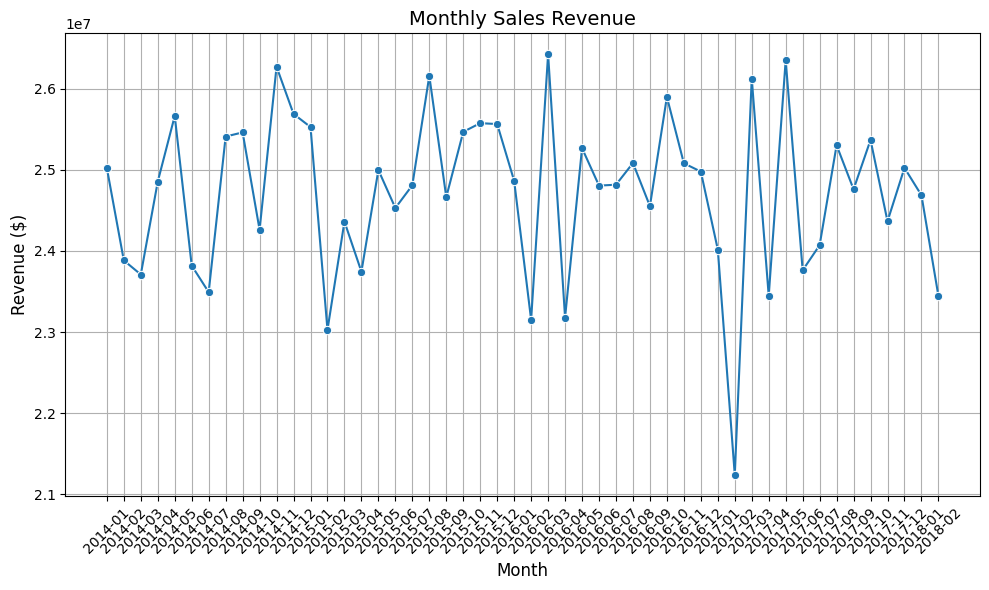

In [ ]:
# Now this is going to be a more detailed graph with each month mentioned

# Convet order_date to datetime
df['year_month'] = df['order_date'].dt.to_period('M')

# Aggregate revenue by year_month
monthly_sales = df.groupby('year_month')['revenue'].sum().reset_index()

# Convert year_month back to string for plotting. Also we converted to strings bcs sns (seaborn) deals better with strings as axis labels instead of numbers
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

# Create the Line Chart
plt.figure(figsize=(10,6))
sns.lineplot(x='year_month', y='revenue', data=monthly_sales, marker='o')
plt.title('Monthly Sales Revenue', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
# .GRID(TRUE) adds grids to the plot
plt.grid(True)
plt.tight_layout()


plt.show()

In [ ]:
"""
The month names ("January," "February," "March") are still like the signs on the piles – they are the index.

Now, .reset_index() is like taking those signs off the piles and writing the month name on a new list next to the amount of money. So, our list changes to:

Month	Money
January	$10 February| $$10 February| $12
March	$9
We've "reset" the index so that the month is now just another piece of information on our list, not the main label for each row.

"""

'\nThe month names ("January," "February," "March") are still like the signs on the piles – they are the index.\n\nNow, .reset_index() is like taking those signs off the piles and writing the month name on a new list next to the amount of money. So, our list changes to:\n\nMonth\tMoney\nJanuary\t$10 February| $$10 February| $12\nMarch\t$9\nWe\'ve "reset" the index so that the month is now just another piece of information on our list, not the main label for each row.\n\n'

In [ ]:
# There was a mistake in the previous graph, we have included the records for January and February 2018 too in the graph which
# results in an biased inaccurate result. Therefore, we are going to remove the year 2018.

# Once again convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Remove the records of Jan & Feb 2018. whatever is NOT (~) in 2018 AND (&) in its first two months is in df_new. basically a NAND gate.
df_new = df[~((df['order_date'].dt.year == 2018) & (df['order_date'].dt.month.isin([1,2])))]

# Now we check if it has been removed. .VALUE_COUNTS() coounts the number of times a unique label has appeared.
# SORT_INDEX() will make it in chronological calendar based order. Otherwise it would have been by descending order of the value count
print("Records after removing the first two months of 2018:")
print(df_new['order_date'].dt.to_period('M').value_counts().sort_index())

Records after removing the first two months of 2018:
order_date
2014-01    1314
2014-02    1237
2014-03    1261
2014-04    1274
2014-05    1322
2014-06    1257
2014-07    1278
2014-08    1290
2014-09    1324
2014-10    1260
2014-11    1319
2014-12    1317
2015-01    1341
2015-02    1199
2015-03    1278
2015-04    1248
2015-05    1281
2015-06    1293
2015-07    1283
2015-08    1331
2015-09    1272
2015-10    1361
2015-11    1262
2015-12    1324
2016-01    1314
2016-02    1189
2016-03    1342
2016-04    1229
2016-05    1322
2016-06    1269
2016-07    1311
2016-08    1287
2016-09    1266
2016-10    1326
2016-11    1278
2016-12    1304
2017-01    1234
2017-02    1134
2017-03    1339
2017-04    1220
2017-05    1348
2017-06    1228
2017-07    1292
2017-08    1269
2017-09    1298
2017-10    1304
2017-11    1284
2017-12    1313
Freq: M, Name: count, dtype: int64


# **Finalized Monthly Sales Trend of All Years**

/tmp/ipython-input-2803222822.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['order_date'] = pd.to_datetime(df_new['order_date'])
/tmp/ipython-input-2803222822.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['month'] = df_new['order_date'].dt.strftime('%B')


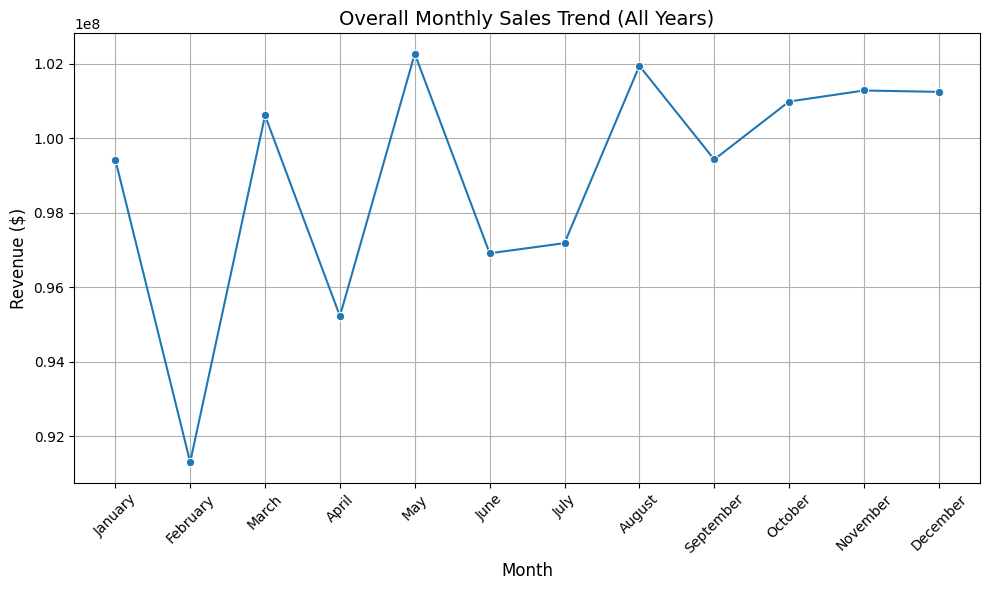

In [ ]:
"""
Now to check seasonality, we are going to aggregate the trends of each month for all the years. Meaning All the Januarys of 2014,2016,2017,
2018 aggregated to figure out the trend for January and so on.

 Extract month name from grouping
.STRFTIME(): This is a powerful method that stands for "string format time".
 It allows you to format a date or time object into a string according to specific codes.
 The %B CODE specifically tells strftime() to give you the full name of the month (like "January" instead of "Jan") """

# Convert order_date to datetime
df_new['order_date'] = pd.to_datetime(df_new['order_date'])


df_new['month'] = df_new['order_date'].dt.strftime('%B')

# Aggregate revenue by month
monthly_trend = df_new.groupby('month')['revenue'].sum().reset_index()


# Sort months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

monthly_trend['month'] = pd.Categorical(monthly_trend['month'], categories=month_order, ordered=True)
monthly_trend = monthly_trend.sort_values('month')

# Create the Line Chart
plt.figure(figsize=(10,6))
sns.lineplot(x='month', y='revenue', data=monthly_trend, marker='o')
plt.title('Overall Monthly Sales Trend (All Years)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()


plt.show()

In [ ]:
""" We used .sort_index() instead of .reset_index() because:
Sorting is the immediate goal: The primary purpose in this line is to get the monthly sales data ordered by month.
Keeping the MultiIndex"""


' We used .sort_index() instead of .reset_index() because:\nSorting is the immediate goal: The primary purpose in this line is to get the monthly sales data ordered by month.\nKeeping the MultiIndex'

In [ ]:
df.to_csv('final.csv')

# **Top 10 Products by Revenue Barplot**

/tmp/ipython-input-1861910145.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(y='revenue', x='product_name', data=top_10_products, palette='tab10')


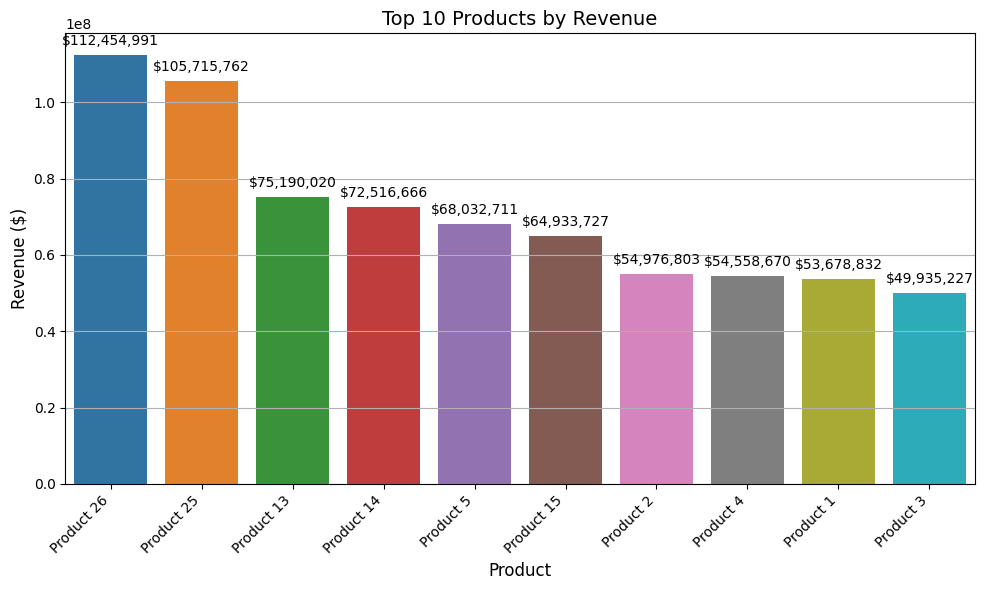

In [ ]:
# Now we are going to create a barchart for the top 10 Products
product_revenue = df_new.groupby('product_name')['revenue'].sum().reset_index()

# Get top ten products based on revenue
top_10_products = product_revenue.sort_values(by='revenue', ascending=False).head(10)

# Create the bar chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(y='revenue', x='product_name', data=top_10_products, palette='tab10')

# Now we add the labels
for p in barplot.patches:
    barplot.annotate(f'${p.get_height():,.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='black',
                     xytext=(0, 5), textcoords='offset points')

plt.title('Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
""" More Detail on the Code:

for p in barplot.patches:: This is how we access each individual bar. barplot.patches is like a list of all the rectangles that make up the bars. The loop takes one rectangle at a time and calls it p.
barplot.annotate(...): This is the function that sticks text onto the plot.
f'${p.get_height():,.0f}': This is the text itself.
p.get_height() gets the revenue number for the current bar.
The f'$ {:, .0f}' part is how we format that number.
$ adds a dollar sign.
, adds commas for thousands separators (e.g., 1,000).
.0f makes sure it's a whole number with no decimal places.
So, if p.get_height() is 112454990.9, this formats it to "$112,454,991".
(p.get_x() + p.get_width() / 2., p.get_height()): This tells where to put the text.
p.get_x() is the left edge of the bar.
p.get_width() / 2. is half the width of the bar.
Adding them together (p.get_x() + p.get_width() / 2.) finds the horizontal center of the bar.
p.get_height() is the top of the bar.
So, this gives us the coordinates right at the top center of each bar.
ha='center', va='bottom': These make sure the text is centered horizontally above the point we specified.
xytext=(0, 5), textcoords='offset points': This moves the text up a little bit (5 points vertically) from
 the top of the bar so it doesn't sit directly on the bar's edge."""

' More Detail on the Code:\n\nfor p in barplot.patches:: This is how we access each individual bar. barplot.patches is like a list of all the rectangles that make up the bars. The loop takes one rectangle at a time and calls it p.\nbarplot.annotate(...): This is the function that sticks text onto the plot.\nf\'${p.get_height():,.0f}\': This is the text itself.\np.get_height() gets the revenue number for the current bar.\nThe f\'$ {:, .0f}\' part is how we format that number.\n$ adds a dollar sign.\n, adds commas for thousands separators (e.g., 1,000).\n.0f makes sure it\'s a whole number with no decimal places.\nSo, if p.get_height() is 112454990.9, this formats it to "$112,454,991".\n(p.get_x() + p.get_width() / 2., p.get_height()): This tells where to put the text.\np.get_x() is the left edge of the bar.\np.get_width() / 2. is half the width of the bar.\nAdding them together (p.get_x() + p.get_width() / 2.) finds the horizontal center of the bar.\np.get_height() is the top of the bar

# **Bottom 10 Products by Revenue Barplot**

/tmp/ipython-input-346668342.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(y='revenue', x='product_name', data=top_10_products, palette='tab10')


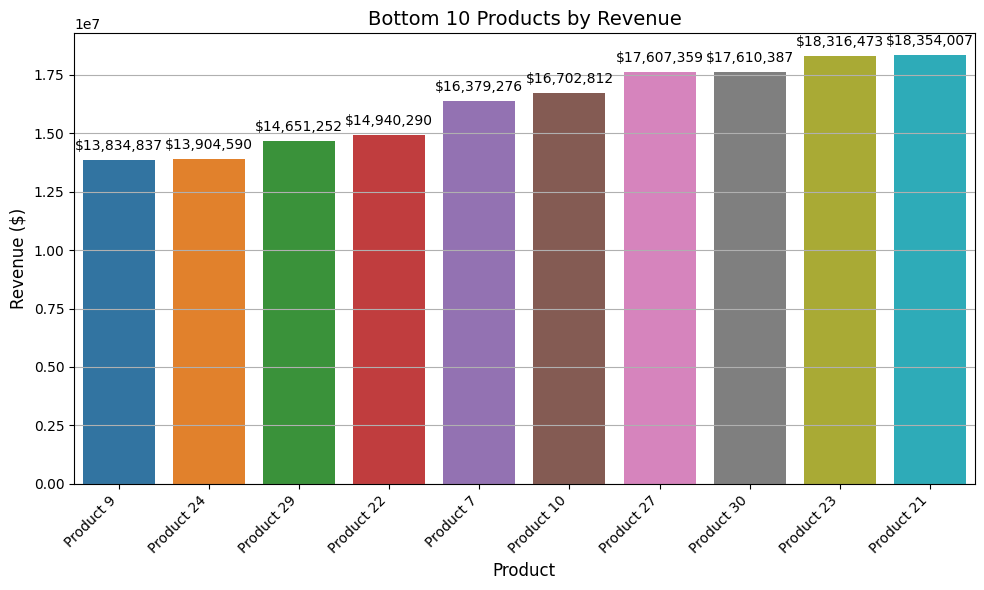

In [ ]:
g# Now we are going to create a barchart for the top 10 Products
product_revenue = df_new.groupby('product_name')['revenue'].sum().reset_index()

# Get top ten products based on revenue
top_10_products = product_revenue.sort_values(by='revenue', ascending=True).head(10)

# Create the bar chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(y='revenue', x='product_name', data=top_10_products, palette='tab10')

# Now we add the labels
for p in barplot.patches:
    barplot.annotate(f'${p.get_height():,.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='black',
                     xytext=(0, 5), textcoords='offset points')

plt.title('Bottom 10 Products by Revenue', fontsize=14)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# **Sales by Channel Pie-Chart**

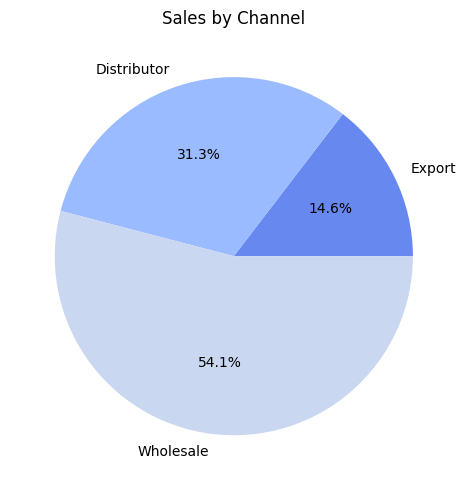

In [ ]:
"""
chan_sales.values: This provides the numerical values for each slice of the pie, which are the revenue sums for each channel.
labels=chan_sales.index: This sets the labels for each slice of the pie, which are the channel names (Export, Distributor, Wholesale).
autopct='%1.1f%%': This formats the percentage value displayed on each slice.

"""

chan_sales = df_new.groupby('channel')['revenue'].sum().sort_values(ascending=True)

plt.figure(figsize=(5, 5))
plt.pie(chan_sales.values,
        labels=chan_sales.index,
        autopct='%1.1f%%',
        colors=sns.color_palette('coolwarm')
)
plt.title('Sales by Channel')

plt.tight_layout()

plt.show()

# **Average Order Value Histogram**

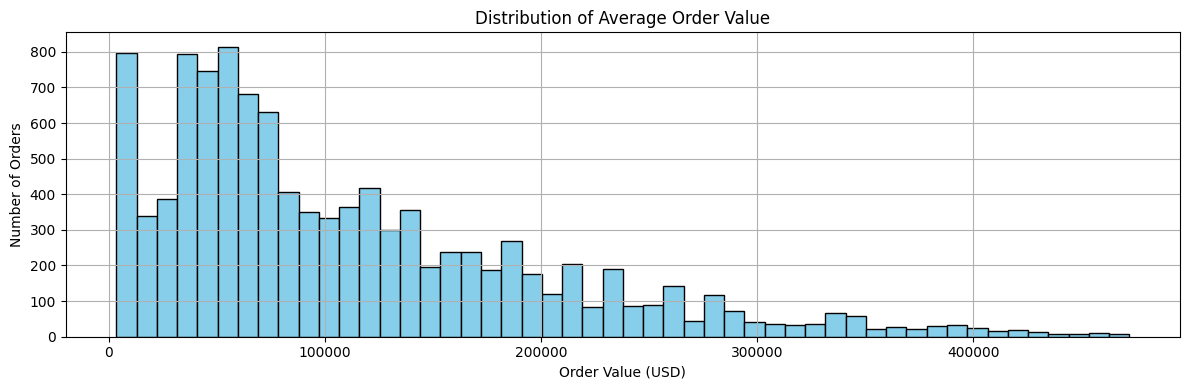

In [ ]:
# Average Order Value (AOV) Distribution
# Its a key performance indicator (KPI) that measures the average dollar amount spent by customers each time they place an order

aov = df_new.groupby('order_number')['revenue'].sum()

plt.figure(figsize=(12,4))

plt.hist(
    aov,
    bins=50,
    color='skyblue',
    edgecolor='black'
)

plt.title('Distribution of Average Order Value')
plt.xlabel('Order Value (USD)')
plt.ylabel('Number of Orders')

plt.grid(True)
plt.tight_layout()

plt.show()

In [ ]:
# We are now going to do the following Analysis too

# Unit Price Distribution per Product
# Top 10 Companies By Revenue and Order Count
# Avergae Profit Margin By Channel
# Top and Bottom 10 Customers by Revenue
# Customer Segmentation : Revenue vs Profit Margin
# Correlation Heatmap

# **Unit Price Distribution per Product**

Chart: Boxplot

EDA Type: Bivariate

Structure: Boxplot with rotated labels to display unit price spread per product



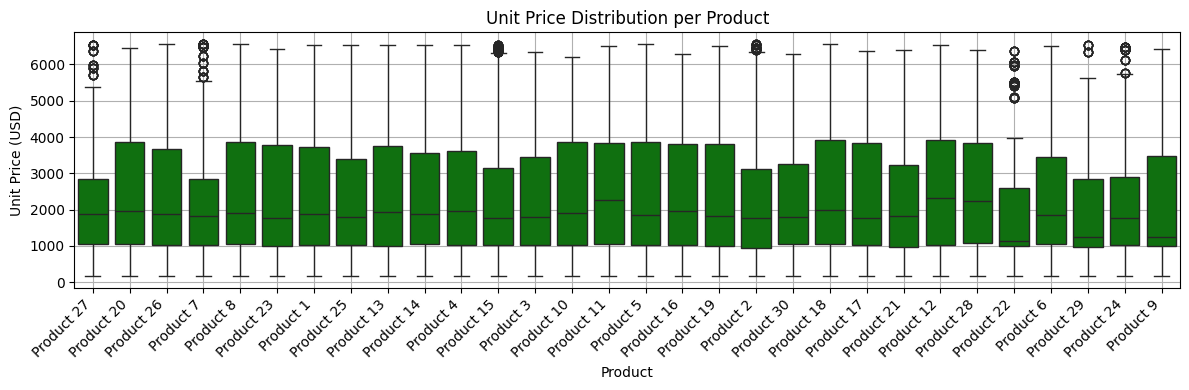

In [ ]:
plt.figure(figsize=(12, 4))

sns.boxplot(
    x='product_name',
    y='unit_price',
    data=df_new,
    color='g')

plt.title('Unit Price Distribution per Product')
plt.xlabel('Product')
plt.ylabel('Unit Price (USD)')

plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()

plt.show()


# **Geographical Choropleth of Sales by State**

In [ ]:
# 1. Aggregate revenue by state (in millions)

import plotly.express as px

state_sales = (
    df
    .groupby('state')['revenue']
    .sum()
    .reset_index()
)
state_sales['revenue_m'] = state_sales['revenue'] / 1e6  # convert to millions

# 2. Plotly choropleth
fig = px.choropleth(
    state_sales,
    locations='state',            # column with state codes
    locationmode='USA-states',    # tells Plotly these are US states
    color='revenue_m',
    scope='usa',
    labels={'revenue_m':'Total Sales (M USD)'},
    color_continuous_scale='Blues',
    hover_data={'revenue_m':':.2f'}  # show 2 decimals
)

# 3. Layout tuning. dict here means I assigned a dictionary two times for setting layout as a whole : once to set the margins
# of the heading, and the second time for the key bar which is on the right.
fig.update_layout(
    title_text='Total Sales by State',
    margin=dict(l=0, r=0, t=40, b=0),
    coloraxis_colorbar=dict(
        title='Sales (M USD)',
        # ticksuffix means adding 'M' after each number in the Key Bar
        ticksuffix='M'
    )
)

fig.show()



# **Correlation Matrix of the Table**